In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import random
import copy
import json
import math
import pickle
from fractions import Fraction
from decimal import Decimal

from itertools import permutations

from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
from qiskit.compiler import transpile
from qiskit.visualization import plot_histogram
from qiskit.circuit.library.standard_gates import SwapGate, PhaseGate
from qiskit.circuit.library import QFT

# from qiskit.algorithms import EstimationProblem, AmplitudeEstimation
from qiskit_algorithms import EstimationProblem, AmplitudeEstimation
# from qiskit.primitives import Sampler
from qiskit.primitives import StatevectorSampler



from binary_optimizer import *


%load_ext autoreload
%autoreload 2


In [2]:
DATADIR = 'binprob_data'

# Just checking the circuit works right

wind demand 2
{'101011': 0.0024, '000101': 0.0414, '010101': 0.002, '011110': 0.0017, '100101': 0.0504, '111011': 0.0383, '010011': 0.0673, '001110': 0.002, '110101': 0.0029, '111101': 0.0419, '101110': 0.0043, '000011': 0.0449, '111110': 0.0447, '100110': 0.0685, '000110': 0.0441, '011101': 0.0041, '001101': 0.0695, '101101': 0.1206, '011011': 0.1192, '010110': 0.0534, '100011': 0.0015, '110110': 0.118, '110011': 0.0047, '001011': 0.0522}
6.73382
wind demand 1
{'001010': 0.0021, '011100': 0.0019, '101010': 0.0009, '011001': 0.0691, '110001': 0.0022, '100001': 0.0039, '010100': 0.0017, '010001': 0.003, '100010': 0.0032, '101100': 0.0677, '101001': 0.0535, '001100': 0.0048, '000100': 0.0468, '111001': 0.0418, '000001': 0.0418, '110010': 0.0609, '011010': 0.0514, '111010': 0.0395, '100100': 0.1115, '111100': 0.0443, '010010': 0.1217, '000010': 0.0437, '110100': 0.0602, '001001': 0.1224}
1.68609
wind demand 0
{'100000': 0.1261, '101000': 0.1253, '011000': 0.1297, '111000': 0.1248, '000000

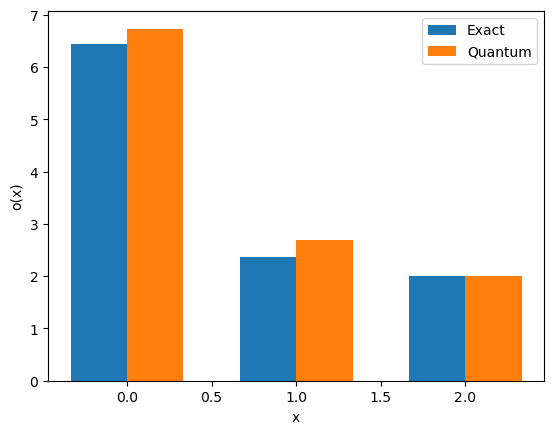

In [3]:
pdf = {(0,0,0): 1/8, (0,0,1): 1/8, (0,1,0): 1/8, (1,0,0): 1/8, (1,1,0): 1/8, (1,0,1): 1/8, (0,1,1): 1/8, (1,1,1): 1/8}
demand = 2
cy = [0.1, 0.2, 0.15]
cr = 10
cx = [1,]
bno = BinaryNestedOptimizer(cx, cy, cr, pdf, demand, True)
demand_surface = bno.brute_force_wind_demand_expectation_values()

# should be 0, 5.075 
# second val is cr*.5 + c_2*.5 (since gen2 is the cheapest available in scenario 011)
# print("expectation value surface")
# print(demand_surface)
obj_x = bno.brute_force_energy_surface()
# print("objective function surface")
# print(obj_x)
# plt.bar(obj_x.keys(), obj_x.values())
# plt.xlabel("x")
# plt.ylabel(r"o(x)")
# plt.show()

obj_x_qc = {}
for x in range(demand+1):
    wind_demand = demand-x
    print('wind demand',wind_demand)
    Uopt = bno.adiabatic_evolution_circuit(wind_demand, time=50, time_steps=5, norm=5)
    #print(Uopt)
    opt_counts = bno.execute_optimizer(Uopt, num_meas=10_000)
    print(opt_counts)
    opt_expectation_value = bno.process_expectation_value_optimizer(wind_demand, opt_counts)
    print(opt_expectation_value)
    obj_x_qc[x] = x*cx[0] + opt_expectation_value

    
exact_vals = [obj_x[x] for x in range(demand+1)]
quantum_vals = [obj_x_qc[x] for x in range(demand+1)]
indices = [x for x in range(demand+1)] # sum(x) values [remember if sum(x_j) = sum(x_i), E(x_j) = E(x_i)]
# Calculate optimal width
width = np.min(np.diff(indices))/3
print(indices)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111)
# matplotlib 3.0 you have to use align
ax.bar(indices-width, exact_vals, width, label='Exact', align='edge')
ax.bar(indices, quantum_vals, width, label='Quantum', align='edge')

ax.set_ylabel('o(x)')
ax.set_xlabel('x')
ax.legend()
plt.show()

# Choose a single demand and minimize

In [4]:
pdf = {(0,0,0): 1/8, (0,0,1): 1/8, (0,1,0): 1/8, (1,0,0): 1/8, 
       (1,1,0): 1/8, (1,0,1): 1/8, (0,1,1): 1/8, (1,1,1): 1/8}
demand = 2
cy = [0.1, 0.2, 0.15]
cr = 10
cx = [1,]
bno = BinaryNestedOptimizer(cx, cy, cr, pdf, demand, True)

# brute force the wind expectation values
demand_surface = bno.brute_force_wind_demand_expectation_values()
print('expectation values', demand_surface)
# brute force the entire energy surface
obj_x = bno.brute_force_energy_surface()
print('energy surface', obj_x)

expectation values [np.float64(0.0), np.float64(1.3624999999999998), np.float64(6.449999999999999)]
energy surface {2: np.float64(2.0), 1: np.float64(2.3625), 0: np.float64(6.449999999999999)}


In [5]:
# choose one demand, and minimize time
demand = 2
x = 1
ydemand = demand - x

times = list(range(1,10))#np.linspace(1,10,10)
time_steps = 4
obj_fns = []
for time in times:
    time_steps = int(time)
    # uopt
    Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=5)
    # execute uopt
    opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
    # post-process to get the expectation value
    opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
    # save objective function
    obj_fn = x*cx[0] + opt_expectation_value
    obj_fns.append(obj_fn)
    


thread '<unnamed>' panicked at crates/transpiler/src/passes/basis_translator/compose_transforms.rs:186:9:
internal error: entered unreachable code: Having a unitary result from an `EquivalenceLibrary is not possible
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


PanicException: internal error: entered unreachable code: Having a unitary result from an `EquivalenceLibrary is not possible

In [ ]:
plt.scatter(times, obj_fns)
plt.plot(times, [obj_x[x] for _ in times])

# Show how the oracle sin approximation works

In [ ]:
n = 4
m = 4
c = 1
shots = 10000
a_list = []
true_a = []
for cy in np.linspace(0.01, 0.25, 10):
    # compute true value
    true_a.append(n/2*cy)
    
    qc = QuantumCircuit(m+n+1,1)
    for i in range(m,m+n):
        qc.h(i)
        qc.cry(cy*np.pi*c, i, m+n)
    
    qc.measure(n+m,0)
    simulator = Aer.get_backend('statevector_simulator')
    qc = transpile(qc, simulator)
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()
    if '1' in counts.keys():
        a_list.append(counts['1']/shots/c)
    else:
        a_list.append(0)
print(a_list)
plt.plot(true_a)
plt.plot(a_list)

In [ ]:
class PrepAExample(QuantumCircuit):
    def __init__(self, qubits, cy):
        super().__init__(qubits+1)
        
        for i in range(qubits):
            self.h(i)
            self.cry(cy*np.pi, i, qubits)

In [ ]:
# create estimator
problem = EstimationProblem(
    state_preparation=PrepAExample(4, .5),  # A operator
    objective_qubits=[4],  # the "good" state Psi1 is identified as measuring |1> in qubit 0
)

sampler = StatevectorSampler()
# sampler = Sampler()

# use qiskit amplitude estimator
ae = AmplitudeEstimation(
    num_eval_qubits=5,  # the number of evaluation qubits specifies circuit width and accuracy
    sampler=sampler,
)

ae_result = ae.estimate(problem)
ae_result.estimation, ae_result.mle

In [ ]:
n = 4
m = 5
c = 1
shots = 10000
a_list = []
true_a = []
estimated_a = []
for cy in np.linspace(0.01, 0.25, 10):
    # compute true value
    true_a.append(n/2*cy)
    
    # measure the ancilla
    qc = QuantumCircuit(m+n+1,1)
    for i in range(m,m+n):
        qc.h(i)
        qc.cry(cy*np.pi*c, i, m+n)
    
    qc.measure(n+m,0)
    simulator = Aer.get_backend('statevector_simulator')
    qc = transpile(qc, simulator)
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()
    if '1' in counts.keys():
        a_list.append(counts['1']/shots/c)
    else:
        a_list.append(0)
        
    # QAE for the ancilla
    problem = EstimationProblem(
        state_preparation=PrepAExample(n, cy),  # A operator
        objective_qubits=[n],  # the "good" state Psi1 is identified as measuring |1> in qubit 0
    )

    sampler = StatevectorSampler()
    # sampler = Sampler()

    # use qiskit amplitude estimator
    ae = AmplitudeEstimation(
        num_eval_qubits=m,  # the number of evaluation qubits specifies circuit width and accuracy
        sampler=sampler,
    )

    ae_result = ae.estimate(problem)    
    estimated_a.append(ae_result.estimation)
    
print(a_list)
plt.plot(true_a)
plt.plot(a_list)
plt.plot(estimated_a)

In [ ]:
cys = np.linspace(0.01, 0.25, 10)
plt.plot(cys, true_a, '-o')
plt.plot(cys, a_list, '-o')
plt.plot(cys, estimated_a, '-o')

# Show TTS for system with PDF

In [ ]:
true_vals = []
quantum_vals = []
for n in range(1,8):
    # get largest subspace
    subspaces_size = sorted([(yd,math.comb(n,yd)) for yd in range(n)], key = lambda a: a[1])
    ydemand = subspaces_size[-1][0]
    
    # get iid s
    pdf = {}
    for xi in range(2**n):
        bstr = ('{0:0'+str(n)+'b}').format(xi)
        sample_tuple = tuple([int(i) for i in bstr])
        pdf[sample_tuple] = 1/2**n
    
    
    # costs
    cy = np.linspace(0.01, 0.1, n)
    cr = .99
    cx = [.5,]
    bno = BinaryNestedOptimizer(cx, cy, cr, pdf, ydemand, True)
    
    # brute force second stage
    exp_val_brute = bno.brute_force_wind_demand_expectation_values()
    true_vals.append(exp_val_brute[ydemand])
    
    # quantum alg. for second stage
    time = n**2#n**2#np.log2(n)
    time_steps = n**2
    # uopt
    Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
    # execute uopt
    opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
    # post-process to get the expectation value
    opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
    quantum_vals.append(opt_expectation_value)
    print(n, true_vals[-1], quantum_vals[-1])
    

In [ ]:
plt.plot(true_vals)
plt.plot(quantum_vals)

# Show scaling for a specific scenario

In [ ]:
true_vals = []
quantum_vals = []
for n in range(2,17):
    # get largest subspace
    subspaces_size = sorted([(yd,math.comb(n,yd)) for yd in range(n)], key = lambda a: a[1])
    ydemand = subspaces_size[-1][0]
    size = subspaces_size[-1][1]
    #print(n,size,int(np.log2(size)), int(np.log2(np.log2(size))), ydemand*cr)
    
    # get a single scenario - half on
    scenario = tuple([1 if i%2 == 0 else 0 for i in range(n)])
    scenario_bstr = ''.join(str(i) for i in scenario[::-1])
    pdf = {scenario: 1.,}
    
    # costs
    cy = np.linspace(0.1, 1, n)
    cr = 9.9
    cx = [3,]
    bno = BinaryNestedOptimizer(cx, cy, cr, pdf, ydemand, True)
    #print(bno.demand_constraint_preserving_mixer(1))
    #if n==7: break
    # brute force second stage
    exp_val_brute = bno.brute_force_wind_demand_expectation_values()
    true_vals.append(exp_val_brute[ydemand])
    
    # quantum alg. for second stage
    #loglog = int(np.log2(np.log2(size)))
    #loglog = 1 if loglog==0 else loglog
    #time_steps = n*int(np.log2(n))#int(np.log2(size))*loglog
    #time_steps = n*int(np.log2(n))
    
    time = n**1.5#n*np.log2(n)
    time_steps = int(time*1) #int(np.ceil(time))
    #time_steps = n
    #time = time_steps
    print(n, time, time_steps)
    
    # uopt
    Uopt = bno.adiabatic_evolution_scenario_circuit(ydemand, time, time_steps, scenario, norm=10.)
    # execute uopt
    opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
    # stitch on the scenario so our analysis software works
    opt_counts = {scenario_bstr+outcome: val for outcome,val in opt_counts.items()}
    # post-process to get the expectation value
    opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
    quantum_vals.append(opt_expectation_value)
    #if n == 4:
    #    break
    

In [ ]:
plt.plot(true_vals)
plt.plot(quantum_vals)

##### pause

## Test 1 - single scenario, n=2-16

In [ ]:
run_record_square = {}

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 30
samples = 50#samples_1-samples_0
nmin = 2
nmax = 19


for n in range(nmin, nmax):
    print('n',n)
    # get largest subspace
    #subspaces_size = sorted([(yd,math.comb(n,yd)) for yd in range(n)], key = lambda a: a[1])
    #ydemand = subspaces_size[-1][0]
    #size = subspaces_size[-1][1]
    #print(n,size,int(np.log2(size)), int(np.log2(np.log2(size))))
    
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    cost_spectrum_x = np.linspace(0.2,0.7, samples)
    random.shuffle(cost_spectrum_x)
    
    # get a single scenario - half on
    scenario = tuple([1 if i%2 == 0 else 0 for i in range(n)])
    scenario_bstr = ''.join(str(i) for i in scenario[::-1])
    pdf = {scenario: 1.,}
    for sample in range(samples_0, samples_1):
        #if sample%5==0:
        #    print('sample', sample)
        print(sample, end=',')
        run_record_square[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [cost_spectrum_x[sample],] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n, True)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        run_record_square[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    loglog = int(np.log2(np.log2(size)))
                    loglog = 1 if loglog==0 else loglog
                    time_steps = n**2#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_scenario_circuit(ydemand, time, time_steps, scenario, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # stitch on the scenario so our analysis software works
                opt_counts = {scenario_bstr+outcome: val for outcome,val in opt_counts.items()}
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value
            else:
                obj_x_qc[x] = cx[0]*x
        
        run_record_square[(n,sample)]['qc_energy_surface'] = obj_x_qc

In [ ]:
with open("binprob_data/run_record_square_alltoall.json", "w") as outfile: 
    json.dump({str(key):val for key, val in run_record_square.items()}, outfile)

In [ ]:
nmin = 2
nmax = 19
samples = 30
xd = []
yd = []
for n in range(nmin,nmax):
    for sample in range(samples):
        xd.append(n)
        results = run_record_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        # rel diff
        abs_val = 0
        rel_diff = 0
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        numerator = sum([np.abs(qc_vec[i] - true_vec[i]) for i in range(n+1)])
        denominator = np.linalg.norm(np.array(true_vec))
        rel_err = numerator/denominator
        #yd.append(rel_err)
        
        yd.append(((np.array(true_vec).T)/np.linalg.norm(true_vec))@(np.array(qc_vec)/np.linalg.norm(qc_vec)))
        
        
plt.scatter(xd,yd)

In [ ]:
results = run_record_square[(18,18)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']

plt.bar(true.keys(), true.values())
plt.plot(qc.keys(), qc.values(), '-D', color='orange')

In [ ]:
run_record_linear = {}

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 30
samples = 50#samples_1-samples_0
nmin = 2
nmax = 19


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    cost_spectrum_x = np.linspace(0.2,0.7, samples)
    random.shuffle(cost_spectrum_x)
    
    # get a single scenario - half on
    scenario = tuple([1 if i%2 == 0 else 0 for i in range(n)])
    scenario_bstr = ''.join(str(i) for i in scenario[::-1])
    pdf = {scenario: 1.,}
    for sample in range(samples_0, samples_1):
        if sample%5==0:
            print('sample', sample)
        run_record_linear[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [cost_spectrum_x[sample],] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n, True)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        run_record_linear[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    loglog = int(np.log2(np.log2(size)))
                    loglog = 1 if loglog==0 else loglog
                    time_steps = n#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_scenario_circuit(ydemand, time, time_steps, scenario, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # stitch on the scenario so our analysis software works
                opt_counts = {scenario_bstr+outcome: val for outcome,val in opt_counts.items()}
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value
            else:
                obj_x_qc[x] = cx[0]*x
        
        run_record_linear[(n,sample)]['qc_energy_surface'] = obj_x_qc

In [ ]:
with open("binprob_data/run_record_linear_alltoall.json", "w") as outfile: 
    json.dump({str(key):val for key, val in run_record_linear.items()}, outfile)

In [ ]:
nmin = 2
nmax = 19
samples = 20
xd = []
yd = []
for n in range(nmin,nmax):
    for sample in range(samples):
        xd.append(n)
        results = run_record_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        # rel diff
        abs_val = 0
        rel_diff = 0
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        
        numerator = sum([np.abs(qc_vec[i] - true_vec[i]) for i in range(n+1)])
        denominator = np.linalg.norm(np.array(true_vec))
        rel_err = numerator/denominator
        #yd.append(rel_err)
        
        yd.append(((np.array(true_vec).T)/np.linalg.norm(true_vec))@(np.array(qc_vec)/np.linalg.norm(qc_vec)))
plt.scatter(xd,yd)

In [ ]:
results = run_record_linear[(18,3)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']

plt.bar(true.keys(), true.values())
plt.plot(qc.keys(), qc.values(), '-D', color='orange')

In [ ]:
run_record_exp = {}

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 10
samples_1 = 30
samples = 50# samples_1-samples_0
nmin = 18
nmax = 19


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    cost_spectrum_x = np.linspace(0.2,0.7, samples)
    random.shuffle(cost_spectrum_x)
    
    # get a single scenario - half on
    scenario = tuple([1 if i%2 == 0 else 0 for i in range(n)])
    scenario_bstr = ''.join(str(i) for i in scenario[::-1])
    pdf = {scenario: 1.,}
    for sample in range(samples_0, samples_1):
        print(sample, end=',')
        run_record_exp[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [cost_spectrum_x[sample],] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n, True)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        run_record_exp[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    #loglog = int(np.log2(np.log2(size)))
                    #loglog = 1 if loglog==0 else loglog
                    time_steps = int(np.sqrt(2**n))
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_scenario_circuit(ydemand, time, time_steps, scenario, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # stitch on the scenario so our analysis software works
                opt_counts = {scenario_bstr+outcome: val for outcome,val in opt_counts.items()}
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value
            else:
                obj_x_qc[x] = cx[0]*x
        
        run_record_exp[(n,sample)]['qc_energy_surface'] = obj_x_qc

In [ ]:
with open("binprob_data/run_record_exp_alltoall.json", "w") as outfile: 
    json.dump({str(key):val for key, val in run_record_exp.items()}, outfile)

In [ ]:
results = run_record_exp[(17,25)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']

plt.bar(true.keys(), true.values())
plt.plot(qc.keys(), qc.values(), '-D', color='orange')

In [ ]:
with open("binprob_data/run_record_linear_alltoall.json", 'r') as json_file:
    run_record_linear = json.load(json_file)
    run_record_linear = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_linear.items()}
    run_record_linear = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_linear.items()}
    
with open("binprob_data/run_record_square_alltoall.json", 'r') as json_file:
    run_record_square = json.load(json_file)
    run_record_square = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_square.items()}
    run_record_square = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_square.items()}
    
with open("binprob_data/run_record_exp_alltoall.json", 'r') as json_file:
    run_record_exp = json.load(json_file)
    run_record_exp = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_exp.items()}
    run_record_exp = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_exp.items()}

In [ ]:
# combine linear and quadratic plot
nmin = 2
nmax = 18
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
ydexpmeans = []
ydexplower = []
ydexpupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    ydexp = []
    for sample in range(samples):
        
        # linear
        results = run_record_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydlin.append(true_vec.T @ qc_vec)
        
        # quadratic
        results = run_record_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydquad.append(true_vec.T @ qc_vec)
            
        # exp
        results = run_record_exp[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydexp.append(true_vec.T @ qc_vec)
        
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)
    # process exp
    mexp = np.mean(ydexp)
    ydexpmeans.append(mexp)
    ydexplower.append(mexp-np.min(ydexp))
    ydexpupper.append(np.max(ydexp)-mexp)

plt.ylabel(r'$o^To_{qc}$')
plt.xlabel(r'$n$')
#plt.ylim([0.94, 1.001])
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.3)
plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.3)
plt.fill_between(xd, np.array(ydexpmeans)-np.array(ydexplower), np.array(ydexpmeans)+np.array(ydexpupper), alpha=.3)
#plt.errorbar(xd,ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
#plt.errorbar(xd,ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
#plt.errorbar(xd,ydexpmeans, [ydexplower, ydexpupper], label=r'$\sqrt{2^n}$')
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$')
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$')
plt.plot(xd,ydexpmeans, '-d', label=r'$\sqrt{2^n}$')
plt.legend(loc='lower right')

In [ ]:
# get difference in answers
# combine linear and quadratic plot
nmin = 2
nmax = 18
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
ydexpmeans = []
ydexplower = []
ydexpupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    ydexp = []
    for sample in range(samples):
        
        # linear
        results = run_record_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydlin.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        
        # quadratic
        results = run_record_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydquad.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        #x_min = min(true, key=true.get)
        #x_qc = min(qc, key=qc.get)
        #o_qc = true[x_qc]
        #ydquad.append(np.abs(true[x_min]-o_qc)/true[x_min])
        
        # sqrt exponential
        results = run_record_exp[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydexp.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)
    
    # process exp
    mexp = np.mean(ydexp)
    ydexpmeans.append(mexp)
    ydexplower.append(mexp-np.min(ydexp))
    ydexpupper.append(np.max(ydexp)-mexp)
    

#plt.ylim([0.9, 1.01])
plt.ylabel(r'$|o^*-o^*_{qc}|/o^*$')
plt.xlabel(r'$n$')
#plt.errorbar(xd, ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
#plt.errorbar(xd, ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
#plt.errorbar(xd, ydexpmeans, [ydexplower, ydexpupper], label=r'$T=\sqrt{2^n}$')
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.2)
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$')

plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.2)
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$')

plt.fill_between(xd, np.array(ydexpmeans)-np.array(ydexplower), np.array(ydexpmeans)+np.array(ydexpupper), alpha=.2)
plt.plot(xd,ydexpmeans, '-d', label=r'$\sqrt{2^n}$')
plt.legend()

# Compute energy surfaces, PDF included (max n~10) & i.i.d.

In [ ]:
run_record_pdf_linear = {}

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 30
samples = 50# samples_1-samples_0
nmin = 2
nmax = 11


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    cost_spectrum_x = np.linspace(0.2,0.6, samples)
    random.shuffle(cost_spectrum_x)
    
    # get iid pdf
    pdf = {}
    for xi in range(2**n):
        bstr = ('{0:0'+str(n)+'b}').format(xi)
        sample_tuple = tuple([int(i) for i in bstr])
        pdf[sample_tuple] = 1/2**n
        
    for sample in range(samples_0, samples_1):
        print(sample, end=',')
        run_record_pdf_linear[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [cost_spectrum_x[sample],] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        run_record_pdf_linear[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    loglog = int(np.log2(np.log2(size)))
                    loglog = 1 if loglog==0 else loglog
                    time_steps = n#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value
            else:
                obj_x_qc[x] = cx[0]*x
        
        run_record_pdf_linear[(n,sample)]['qc_energy_surface'] = obj_x_qc

In [ ]:
with open("binprob_data/run_record_pdf_linear.json", "w") as outfile: 
    json.dump({str(key):val for key, val in run_record_pdf_linear.items()}, outfile)

In [ ]:
nmin = 2
nmax = 11
samples = 10
xd = []
yd = []
for n in range(nmin,nmax):
    for sample in range(samples):
        xd.append(n)
        results = run_record_pdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        # rel diff
        abs_val = 0
        rel_diff = 0
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        numerator = sum([np.abs(qc_vec[i] - true_vec[i]) for i in range(n+1)])
        denominator = np.linalg.norm(np.array(true_vec))
        rel_err = numerator/denominator
        #yd.append(rel_err)
        
        yd.append(((np.array(true_vec).T)/np.linalg.norm(true_vec))@(np.array(qc_vec)/np.linalg.norm(qc_vec)))
plt.scatter(xd,yd)

In [ ]:
results = run_record_pdf_linear[(10,9)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']

plt.bar(true.keys(), true.values())
plt.plot(qc.keys(), qc.values(), '-D', color='orange')

In [ ]:
run_record_pdf_square = {}

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 30
samples = 50# samples_1-samples_0
nmin = 2
nmax = 11


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    cost_spectrum_x = np.linspace(0.2, 0.6, samples)
    random.shuffle(cost_spectrum_x)
    
    # get iid pdf
    pdf = {}
    for xi in range(2**n):
        bstr = ('{0:0'+str(n)+'b}').format(xi)
        sample_tuple = tuple([int(i) for i in bstr])
        pdf[sample_tuple] = 1/2**n
        
    for sample in range(samples_0, samples_1):
        print(sample, end=',')
        run_record_pdf_square[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [cost_spectrum_x[sample],] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        run_record_pdf_square[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    loglog = int(np.log2(np.log2(size)))
                    loglog = 1 if loglog==0 else loglog
                    time_steps = n**2#n#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value
            else:
                obj_x_qc[x] = cx[0]*x
        
        run_record_pdf_square[(n,sample)]['qc_energy_surface'] = obj_x_qc

In [ ]:
with open("binprob_data/run_record_pdf_square.json", "w") as outfile: 
    json.dump({str(key):val for key, val in run_record_pdf_square.items()}, outfile)

In [ ]:
with open("binprob_data/run_record_pdf_linear.json", 'r') as json_file:
    run_record_pdf_linear = json.load(json_file)
    run_record_pdf_linear = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_pdf_linear.items()}
    run_record_pdf_linear = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_pdf_linear.items()}
    
with open("binprob_data/run_record_pdf_square.json", 'r') as json_file:
    run_record_pdf_square = json.load(json_file)
    run_record_pdf_square = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_pdf_square.items()}
    run_record_pdf_square = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_pdf_square.items()}

In [ ]:
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_pdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydlin.append(true_vec.T @ qc_vec)
        
        # quadratic
        results = run_record_pdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydquad.append(true_vec.T @ qc_vec)
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)

plt.ylabel(r'$o^To_{qc}$')
plt.xlabel(r'$n$')
plt.ylim([0.95, 1.001])
plt.errorbar(xd,ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
plt.errorbar(xd,ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
plt.legend()

In [ ]:
# get difference in answers
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_pdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydlin.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        
        # quadratic
        results = run_record_pdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydquad.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)

#plt.ylim([-0.01, 1.01])
plt.ylabel(r'$|o^*-o^*_{qc}|/o^*$')
plt.xlabel(r'$n$')
plt.errorbar(xd,ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
plt.errorbar(xd,ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
plt.legend()

In [ ]:
n = 9
sample = 6
results = run_record_pdf_linear[(n,sample)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']

plt.axvline(x=min(true, key=true.get))
plt.axvline(x=min(qc, key=qc.get), color='orange')
plt.bar(true.keys(), true.values())
plt.plot(qc.keys(), qc.values(), '-D', color='orange')

results = run_record_pdf_square[(n,sample)]
qc = results['qc_energy_surface']
plt.axvline(x=min(qc, key=qc.get), color='red')
plt.plot(qc.keys(), qc.values(), '-D', color='red')

In [ ]:
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_pdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        #true_vec = true_vec[1:-1]
        #true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        #qc_vec = qc_vec[1:-1]
        #qc_vec /= np.linalg.norm(qc_vec)
        #ydlin.append(true_vec.T @ qc_vec)
        ydlin.append(np.sum(np.abs(true_vec-qc_vec)/true_vec))
        #if ydlin[-1] > 1.8 or ydlin[-1] == 0:
        #    print('l', ydlin[-1], n, sample)
        
        # quadratic
        results = run_record_pdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        #true_vec = true_vec[1:-1]
        #true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        #qc_vec = qc_vec[1:-1]
        #qc_vec /= np.linalg.norm(qc_vec)
        #ydquad.append(true_vec.T @ qc_vec)
        ydquad.append(np.sum(np.abs(true_vec-qc_vec)/true_vec))
        #if ydquad[-1] > 1.8 or ydquad[-1] < .20:
        #    print('q', ydquad[-1], n, sample)
        
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)

plt.ylabel(r'$|o(x) - \tilde{o}(x)|/o(x)$')
plt.xlabel(r'$n$')
#plt.ylim([0.94, 1.001])
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.3, color='tab:orange')
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$', color='tab:orange')

plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.3, color='tab:green')
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$', color='tab:green')

plt.legend(loc='upper left')

In [ ]:
# get difference in answers
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 30
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_pdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydlin.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        
        # quadratic
        results = run_record_pdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydquad.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)
    

#plt.ylim([0.9, 1.01])
plt.ylabel(r'$|o^*-\tilde{o}^*|/o^*$')
plt.xlabel(r'$n$')
#plt.errorbar(xd, ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
#plt.errorbar(xd, ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
#plt.errorbar(xd, ydexpmeans, [ydexplower, ydexpupper], label=r'$T=\sqrt{2^n}$')
plt.fill_between(xd, np.array(ydlinmeans)-np.array(ydlinlower), np.array(ydlinmeans)+np.array(ydlinupper), alpha=.2, color='tab:orange')
plt.plot(xd,ydlinmeans, '-d', label=r'$T=n$', color='tab:orange')

plt.fill_between(xd, np.array(ydquadmeans)-np.array(ydquadlower), np.array(ydquadmeans)+np.array(ydquadupper), alpha=.2, color='tab:green')
plt.plot(xd,ydquadmeans, '-d', label=r'$T=n^2$', color='tab:green')

#plt.fill_between(xd, np.array(ydexpmeans)-np.array(ydexplower), np.array(ydexpmeans)+np.array(ydexpupper), alpha=.2)
#plt.plot(xd,ydexpmeans, '-d', label=r'$\sqrt{2^n}$')
plt.legend(location='top left')

In [ ]:
## Make plots of $o$

# bad line
n = 10
sample = 27 
results = run_record_pdf_linear[(n,sample)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']
true_vec = []
qc_vec = []
for x in range(n+1):
    true_vec.append(true[x])
    qc_vec.append(qc[x])
    
plt.ylabel(r'$o(x)$')
plt.xlabel(r'$x$')
plt.plot(true_vec, '-o')
plt.plot(qc_vec, '-o')
plt.axvline(np.argmin(true_vec), linestyle='-.')
plt.axvline(np.argmin(qc_vec), color='tab:orange', linestyle=':')
plt.show()

# bad line
n = 10
sample = 29
results = run_record_pdf_square[(n,sample)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']
true_vec = []
qc_vec = []
for x in range(n+1):
    true_vec.append(true[x])
    qc_vec.append(qc[x])
    
plt.ylabel(r'$o(x)$')
plt.xlabel(r'$x$')
plt.plot(true_vec, '-o')
plt.plot(qc_vec, '-o', color='tab:green')
plt.axvline(np.argmin(true_vec)+0.02, linestyle='-.')
plt.axvline(np.argmin(qc_vec)-.02, color='tab:green', linestyle=':')

## Get samples for normal dist of PDF 

In [ ]:
# figure out normal dist around weight
n = 3

x = np.arange(-1-int(n/2), int(n/2)+n%2)
prob = scipy.stats.norm.pdf(x, scale=1)
prob = prob / prob.sum()

pdf = {}
for xi in range(2**n):
    bstr = ('{0:0'+str(n)+'b}').format(xi)
    sample_tuple = tuple([int(i) for i in bstr])
    s = sum(sample_tuple)
    size = math.comb(n,s)
    pdf[sample_tuple] = prob[s]/size
    
prob, pdf

In [ ]:
run_record_normalpdf_linear = {}

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 20
samples = samples_1-samples_0
nmin = 2
nmax = 11


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    
    # get the normal pdf
    dist = np.arange(-1-int(n/2), int(n/2)+n%2)
    prob = scipy.stats.norm.pdf(dist, scale=1)
    prob = prob / prob.sum()

    pdf = {}
    for xi in range(2**n):
        bstr = ('{0:0'+str(n)+'b}').format(xi)
        sample_tuple = tuple([int(i) for i in bstr])
        s = sum(sample_tuple)
        size = math.comb(n,s)
        pdf[sample_tuple] = prob[s]/size
        
    for sample in range(samples_0, samples_1):
        if sample%5==0:
            print('sample', sample)
        run_record_normalpdf_linear[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [0.3,] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        run_record_normalpdf_linear[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    loglog = int(np.log2(np.log2(size)))
                    loglog = 1 if loglog==0 else loglog
                    time_steps = n#n#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value
            else:
                obj_x_qc[x] = cx[0]*x
        
        run_record_normalpdf_linear[(n,sample)]['qc_energy_surface'] = obj_x_qc
        
with open("binprob_data/run_record_normalpdf_linear.json", "w") as outfile: 
    json.dump({str(key):val for key, val in run_record_normalpdf_linear.items()}, outfile)

In [ ]:
run_record_normalpdf_square = {}

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 20
samples = samples_1-samples_0
nmin = 2
nmax = 11


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    
    # get the normal pdf
    dist = np.arange(-1-int(n/2), int(n/2)+n%2)
    prob = scipy.stats.norm.pdf(dist, scale=1)
    prob = prob / prob.sum()

    pdf = {}
    for xi in range(2**n):
        bstr = ('{0:0'+str(n)+'b}').format(xi)
        sample_tuple = tuple([int(i) for i in bstr])
        s = sum(sample_tuple)
        size = math.comb(n,s)
        pdf[sample_tuple] = prob[s]/size
        
    for sample in range(samples_0, samples_1):
        if sample%5==0:
            print('sample', sample)
        run_record_normalpdf_square[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [0.3,] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        run_record_normalpdf_square[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    loglog = int(np.log2(np.log2(size)))
                    loglog = 1 if loglog==0 else loglog
                    time_steps = n**2#n#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value
            else:
                obj_x_qc[x] = cx[0]*x
        
        run_record_normalpdf_square[(n,sample)]['qc_energy_surface'] = obj_x_qc
        
with open("binprob_data/run_record_normalpdf_square.json", "w") as outfile: 
    json.dump({str(key):val for key, val in run_record_normalpdf_square.items()}, outfile)

In [ ]:
with open("binprob_data/run_record_normalpdf_linear.json", 'r') as json_file:
    run_record_normalpdf_linear = json.load(json_file)
    run_record_normalpdf_linear = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_normalpdf_linear.items()}
    run_record_normalpdf_linear = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_normalpdf_linear.items()}
    
with open("binprob_data/run_record_normalpdf_square.json", 'r') as json_file:
    run_record_normalpdf_square = json.load(json_file)
    run_record_normalpdf_square = {(int(s.split()[0][1:-1]), int(s.split()[1][:-1])):val for s,val in run_record_normalpdf_square.items()}
    run_record_normalpdf_square = {key0: 
                                   {key1: {int(x):o for x,o in value1.items()} 
                                    for key1,value1 in value0.items()} 
                                   for key0,value0 in run_record_normalpdf_square.items()}


In [ ]:
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 20
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_normalpdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydlin.append(true_vec.T @ qc_vec)
        
        # quadratic
        results = run_record_normalpdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = np.array(true_vec)
        true_vec = true_vec[1:-1]
        true_vec /= np.linalg.norm(true_vec)
        qc_vec = np.array(qc_vec)
        qc_vec = qc_vec[1:-1]
        qc_vec /= np.linalg.norm(qc_vec)
        ydquad.append(true_vec.T @ qc_vec)
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)

plt.ylabel(r'$o^To_{qc}$')
plt.xlabel(r'$n$')
plt.ylim([0.95, 1.001])
plt.errorbar(xd,ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
plt.errorbar(xd,ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
plt.legend()

In [ ]:
# get difference in answers
# combine linear and quadratic plot
nmin = 2
nmax = 11
samples = 20
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydquadmeans = []
ydquadlower = []
ydquadupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydquad = []
    for sample in range(samples):
        
        # linear
        results = run_record_normalpdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydlin.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        
        # quadratic
        results = run_record_normalpdf_square[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qc_energy_surface']
        true_vec = []
        qc_vec = []
        for x in range(n+1):
            true_vec.append(true[x])
            qc_vec.append(qc[x])
        true_vec = true_vec[1:-1]
        qc_vec = qc_vec[1:-1]
        x_min = np.argmin(true_vec)#, key=true.get)
        x_qc = np.argmin(qc_vec,)#, key=qc.get)
        o_qc = true_vec[x_qc]
        ydquad.append(np.abs(true_vec[x_min]-o_qc)/true_vec[x_min])
        #ydquad.append(true[x_min]/o_qc)
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mquad = np.mean(ydquad)
    ydquadmeans.append(mquad)
    ydquadlower.append(mquad-np.min(ydquad))
    ydquadupper.append(np.max(ydquad)-mquad)

#plt.ylim([-0.01, 1.01])
plt.ylabel(r'$|o^*-o^*_{qc}|/o^*$')
plt.xlabel(r'$n$')
plt.errorbar(xd,ydlinmeans,  [ydlinlower, ydlinupper], label=r'$T=n$')
plt.errorbar(xd,ydquadmeans, [ydquadlower, ydquadupper], label=r'$T=n^2$')
plt.legend()

In [ ]:
n = 10
sample = 6
results = run_record_normalpdf_linear[(n,sample)]
true = results['true_energy_surface']
qc = results['qc_energy_surface']
#true_keys = list(true.keys())
#true_keys.sort()
#true = {i: true[i] for i in true_keys}
#qc_keys = list(qc.keys())
#qc_keys.sort()
#qc = {i: qc[i] for i in qc_keys}
#print(qc)


plt.axvline(x=min(true, key=true.get))
plt.axvline(x=min(qc, key=qc.get), color='orange')
plt.bar(true.keys(), true.values())
plt.plot(qc.keys(), qc.values(), '-D', color='orange')

results = run_record_normalpdf_square[(n,sample)]
qc = results['qc_energy_surface']
plt.axvline(x=min(qc, key=qc.get), color='red')
plt.plot(qc.keys(), qc.values(), '-D', color='red')

# Figure out estimation

## Oracle

In [ ]:
n = 3

# get iid pdf
pdf = {}
for xi in range(2**n):
    bstr = ('{0:0'+str(n)+'b}').format(xi)
    sample_tuple = tuple([int(i) for i in bstr])
    pdf[sample_tuple] = 1/2**n
    
cy = [1,.5,1.25,]
cr = 9.5
cx = [3,]
bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)

# brute force second stage
obj_x = bno.brute_force_energy_surface()
print('true:',obj_x)

demand = n
ydemand = 2

x = demand - ydemand
print('demand, ydemand, x', demand, ydemand, x)

time = n
time_steps = time
norm = ydemand*cr
print(norm)

qc = QuantumCircuit(len(cy)*2+1)
Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
# No oracle
opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
# post-process to get the expectation value
opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
print(opt_expectation_value, x*cx[0] + opt_expectation_value)
F = bno.exact_oracle(ydemand, norm)
print(F)
#print(F)
#bno.single_oracle_smallangle_inconstraint(c=c, norm=norm)
qc.append(Uopt, bno.wind_qubits+bno.pdf_qubits)
qc.append(F, list(range(bno.num_wind_vars*2+1)))

#print(F)
a = bno.execute_optimizer_oracle(qc)
print(a, a*norm, a*norm + x*cx[0])

# Compare different tomography techniques 
first at a given system size, then see how the best method scales with system size

In [ ]:
# first, with the uniform superposition
n = 5
samples = 10
sample = 0

cost_spectrum = np.linspace(0.01, 0.1, samples*n)
random.shuffle(cost_spectrum)

# get iid pdf
pdf = {}
for xi in range(2**n):
    bstr = ('{0:0'+str(n)+'b}').format(xi)
    sample_tuple = tuple([int(i) for i in bstr])
    pdf[sample_tuple] = 1/2**n

# costs
cy = cost_spectrum[sample*n:sample*n+n]
cr = 0.99
cx = [0.3,] # 
bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)
obj_x = bno.brute_force_energy_surface() # exact soln
# setup demand y=3 is largest
ydemand = 3
x = n-ydemand
time = n**2
time_steps = time
# uopt
Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)

shots_list = [10,25,50,75,100,250,500,1_000]
estimates_raw = []
for shots in shots_list:
    # quantum compute the second stage
    # quantum alg. for second stage
    obj_x_qc = {}
    # execute uopt
    # Raw shots
    opt_counts = bno.execute_optimizer(copy.deepcopy(Uopt), num_meas=shots)
    # post-process to get the expectation value
    opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
    o_x = cx[0]*x + opt_expectation_value
    print(o_x)
    estimates_raw.append(o_x)
    

In [ ]:
# relative errors
plt.scatter(shots_list, [np.abs(e-obj_x[x])/obj_x[x] for e in estimates_raw])

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 1
samples = samples_1-samples_0
nmin = 6
nmax = 7


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    
    # get the normal pdf
    dist = np.arange(-1-int(n/2), int(n/2)+n%2)
    prob = scipy.stats.norm.pdf(dist, scale=1)
    prob = prob / prob.sum()

    pdf = {}
    for xi in range(2**n):
        bstr = ('{0:0'+str(n)+'b}').format(xi)
        sample_tuple = tuple([int(i) for i in bstr])
        s = sum(sample_tuple)
        size = math.comb(n,s)
        pdf[sample_tuple] = prob[s]/size
        
    for sample in range(samples_0, samples_1):
        if sample%5==0:
            print('sample', sample)
        #run_record_normalpdf_square[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [0.5,] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        #run_record_normalpdf_square[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}     #
        obj_x_qc_mle = {} # 
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    loglog = int(np.log2(np.log2(size)))
                    loglog = 1 if loglog==0 else loglog
                    time_steps = n#n#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value
                # oracle
                qc = QuantumCircuit(2*n+1)
                qc.append(Uopt, list(range(2*n)))
                F = bno.single_oracle_sin_inconstraint(c=1, norm=ydemand*cr)#bno.exact_oracle(ydemand, ydemand*cr)
                qc.append(F, list(range(2*n+1)))
                obj_x_qc_mle[x] = cx[0]*x + ydemand*cr*bno.execute_optimizer_oracle(qc)
            else:
                obj_x_qc[x] = cx[0]*x
                obj_x_qc_mle[x] = cx[0]*x
        
        #run_record_normalpdf_square[(n,sample)]['qc_energy_surface'] = obj_x_qc

In [ ]:
true = obj_x
qc = obj_x_qc
true_qc = obj_x_qc_mle

plt.axvline(x=min(true, key=true.get))
#plt.axvline(x=min(qc, key=qc.get), color='orange')
plt.bar(true.keys(), true.values())
plt.plot(qc.keys(), qc.values(), '-D', color='orange')
plt.plot(true_qc.keys(), true_qc.values(), '-D', color='red')

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 1
samples = samples_1-samples_0
nmin = 5
nmax = 6


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    
    # get the normal pdf
    dist = np.arange(-1-int(n/2), int(n/2)+n%2)
    prob = scipy.stats.norm.pdf(dist, scale=1)
    prob = prob / prob.sum()

    pdf = {}
    for xi in range(2**n):
        bstr = ('{0:0'+str(n)+'b}').format(xi)
        sample_tuple = tuple([int(i) for i in bstr])
        s = sum(sample_tuple)
        size = math.comb(n,s)
        pdf[sample_tuple] = prob[s]/size
        
    for sample in range(samples_0, samples_1):
        if sample%5==0:
            print('sample', sample)
        #run_record_normalpdf_square[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [0.3,] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        #run_record_normalpdf_square[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}     #
        obj_x_qc_mle = {} # 
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    loglog = int(np.log2(np.log2(size)))
                    loglog = 1 if loglog==0 else loglog
                    time_steps = n**2#n#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value # direct estimation - slow but accurate
                
                # oracle
                #qc = QuantumCircuit(2*n+1)
                #qc.append(Uopt, list(range(2*n)))
                #F = bno.single_oracle_sin_inconstraint(c=1, norm=ydemand*cr)#bno.exact_oracle(ydemand, ydemand*cr)
                #qc.append(F, list(range(2*n+1)))
                #obj_x_qc_mle[x] = cx[0]*x + ydemand*cr*bno.execute_optimizer_oracle(qc)
                c = 1.
                norm = ydemand*cr
                m = 2
                est = bno.canonical_qae(Uopt, m, c, norm)
                obj_x_qc_mle[x] = cx[0]*x + est*norm
                
            else:
                obj_x_qc[x] = cx[0]*x
                obj_x_qc_mle[x] = cx[0]*x
        
        
       #     est = bno.canonical_qae(Uopt, m, c, norm)
       #     obj_x_qc[x] = cx[0]*x + est*norm/c
       #     #obj_x_qc[x] = cx[0]*x + (est + c)/(2*c)*(ydemand*cr)
       #     #obj_x_qc[x] = cx[0]*x + est*(ydemand*cr)*.1
       #     #obj_x_qc_mle[x] = cx[0]*x + mle_est
       # else:
       #     obj_x_qc[x] = cx[0]*x
       # #obj_x_qc_mle[x] = cx[0]*x

In [ ]:
true = obj_x
qc = obj_x_qc
true_qc = obj_x_qc_mle

plt.axvline(x=min(true, key=true.get))
#plt.axvline(x=min(qc, key=qc.get), color='orange')
plt.bar(true.keys(), true.values())
plt.plot(qc.keys(), qc.values(), '-D', color='orange')
plt.plot(true_qc.keys(), true_qc.values(), '-D', color='red')

In [ ]:
run_record_qae_mle_2_50_normalpdf_linear = {}

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 20
samples = samples_1-samples_0
nmin = 2
nmax = 9
m = 2


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    
    # get the normal pdf
    dist = np.arange(-1-int(n/2), int(n/2)+n%2)
    prob = scipy.stats.norm.pdf(dist, scale=1)
    prob = prob / prob.sum()

    pdf = {}
    for xi in range(2**n):
        bstr = ('{0:0'+str(n)+'b}').format(xi)
        sample_tuple = tuple([int(i) for i in bstr])
        s = sum(sample_tuple)
        size = math.comb(n,s)
        pdf[sample_tuple] = prob[s]/size
        
    for sample in range(samples_0, samples_1):
        if sample%5==0:
            print('sample', sample)
        run_record_qae_mle_2_50_normalpdf_linear[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [0.3,] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        run_record_qae_mle_2_50_normalpdf_linear[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}     #
        obj_x_qc_mle = {} # 
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    #loglog = int(np.log2(np.log2(size)))
                    #loglog = 1 if loglog==0 else loglog
                    time_steps = n#n#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value # direct estimation - slow but accurate
                
                # oracle
                #qc = QuantumCircuit(2*n+1)
                #qc.append(Uopt, list(range(2*n)))
                #F = bno.single_oracle_sin_inconstraint(c=1, norm=ydemand*cr)#bno.exact_oracle(ydemand, ydemand*cr)
                #qc.append(F, list(range(2*n+1)))
                #obj_x_qc_mle[x] = cx[0]*x + ydemand*cr*bno.execute_optimizer_oracle(qc)
                c = 1.
                norm = ydemand*cr
                m = 2
                est = bno.canonical_qae(Uopt, m, c, norm)
                obj_x_qc_mle[x] = cx[0]*x + est*norm
            else:
                obj_x_qc[x] = cx[0]*x
                
        
        run_record_qae_mle_2_50_normalpdf_linear[(n,sample)]['qae_qc_energy_surface'] = obj_x_qc
        run_record_qae_mle_2_50_normalpdf_linear[(n,sample)]['qae_mle_qc_energy_surface'] = obj_x_qc_mle
 

In [ ]:
       
with open("binprob_data/run_record_qae_mle_2_50_normalpdf_linear.json", "w") as outfile: 
    json.dump({str(key):val for key, val in run_record_qae_mle_2_50_normalpdf_linear.items()}, outfile)

In [ ]:
run_record_qae_mle_2_50_normalpdf_square = {}

In [ ]:
## do the above, for enough instances to get statistics
# first 10 samples
random.seed(0)
true_vals = []
quantum_vals = []
samples_0 = 0
samples_1 = 20
samples = samples_1-samples_0
nmin = 2
nmax = 9
m = 2


for n in range(nmin, nmax):
    print('n',n)
    # costs 
    cost_spectrum = np.linspace(0.01, 0.1, samples*n)
    random.shuffle(cost_spectrum)
    
    # get the normal pdf
    dist = np.arange(-1-int(n/2), int(n/2)+n%2)
    prob = scipy.stats.norm.pdf(dist, scale=1)
    prob = prob / prob.sum()

    pdf = {}
    for xi in range(2**n):
        bstr = ('{0:0'+str(n)+'b}').format(xi)
        sample_tuple = tuple([int(i) for i in bstr])
        s = sum(sample_tuple)
        size = math.comb(n,s)
        pdf[sample_tuple] = prob[s]/size
        
    for sample in range(samples_0, samples_1):
        if sample%5==0:
            print('sample', sample)
        run_record_qae_mle_2_50_normalpdf_square[(n,sample)] = {}
        
        # costs
        cy = cost_spectrum[sample*n:sample*n+n]
        cr = 0.99
        cx = [0.3,] # dummy
        bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)

        # brute force second stage
        obj_x = bno.brute_force_energy_surface()
        run_record_qae_mle_2_50_normalpdf_square[(n,sample)]['true_energy_surface'] = obj_x

        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}     #
        obj_x_qc_mle = {} # 
        for ydemand in range(n+1):
            size = math.comb(n,ydemand)
            x = n-ydemand
            if ydemand != 0:
                # choose our annealing time
                if size > 1:
                    #loglog = int(np.log2(np.log2(size)))
                    #loglog = 1 if loglog==0 else loglog
                    time_steps = n#n#int(np.log2(size))*loglog
                    time = time_steps
                else:
                    time_steps = 0
                    time = 1

                # uopt
                Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
                # execute uopt
                opt_counts = bno.execute_optimizer(Uopt, num_meas=None)
                # post-process to get the expectation value
                opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
                obj_x_qc[x] = cx[0]*x + opt_expectation_value # direct estimation - slow but accurate
                
                # oracle
                #qc = QuantumCircuit(2*n+1)
                #qc.append(Uopt, list(range(2*n)))
                #F = bno.single_oracle_sin_inconstraint(c=1, norm=ydemand*cr)#bno.exact_oracle(ydemand, ydemand*cr)
                #qc.append(F, list(range(2*n+1)))
                #obj_x_qc_mle[x] = cx[0]*x + ydemand*cr*bno.execute_optimizer_oracle(qc)
                c = 1.
                norm = ydemand*cr
                m = 2
                est = bno.canonical_qae(Uopt, m, c, norm)
                obj_x_qc_mle[x] = cx[0]*x + est*norm
            else:
                obj_x_qc[x] = cx[0]*x
                
        
        run_record_qae_mle_2_50_normalpdf_square[(n,sample)]['qae_qc_energy_surface'] = obj_x_qc
        run_record_qae_mle_2_50_normalpdf_square[(n,sample)]['qae_mle_qc_energy_surface'] = obj_x_qc_mle
        
with open("binprob_data/run_record_qae_mle_2_50_normalpdf_square.json", "w") as outfile: 
    json.dump({str(key):val for key, val in run_record_qae_mle_2_50_normalpdf_square.items()}, outfile)

In [ ]:
# get difference in answers
# combine linear and quadratic plot
nmin = 2
nmax = 8
samples = 20
xd = []
ydlinmeans = []
ydlinlower = []
ydlinupper = []
ydmlemeans = []
ydmlelower = []
ydmleupper = []
for n in range(nmin,nmax):
    xd.append(n)
    ydlin = []
    ydmle = []
    for sample in range(samples):
        #print(sample)
        # linear
        results = run_record_qae_mle_2_50_normalpdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qae_qc_energy_surface']
        x_min = min(true, key=true.get)
        x_qc = min(qc, key=qc.get)
        o_qc = true[x_qc]
        ydlin.append(np.abs(true[x_min]-o_qc)/true[x_min])
        #ydlin.append(true[x_min]/o_qc)
        
        # quadratic
        results = run_record_qae_mle_2_50_normalpdf_linear[(n,sample)]
        true = results['true_energy_surface']
        qc = results['qae_mle_qc_energy_surface']
        x_min = min(true, key=true.get)
        x_qc = min(qc, key=qc.get)
        o_qc = true[x_qc]
        ydmle.append(np.abs(true[x_min]-o_qc)/true[x_min])
        #ydquad.append(true[x_min]/o_qc)
    
    # process lin
    mlin = np.mean(ydlin)
    ydlinmeans.append(mlin)
    ydlinlower.append(mlin-np.min(ydlin))
    ydlinupper.append(np.max(ydlin)-mlin)
    # process quad
    mmle = np.mean(ydmle)
    ydmlemeans.append(mmle)
    ydmlelower.append(mmle-np.min(ydmle))
    ydmleupper.append(np.max(ydmle)-mmle)

#plt.ylim([-0.01, 1.01])
plt.ylabel(r'$|o^*-o^*_{qc}|/o^*$')
plt.xlabel(r'$n$')
plt.errorbar(xd,ydlinmeans,  [ydlinlower, ydlinupper], label=r'statevector')
plt.errorbar(xd,ydmlemeans, [ydmlelower, ydmleupper], label=r'qae-mle, shots=50')
plt.legend()

In [ ]:
n = 8
sample = 7
results = run_record_qae_normalpdf_linear[(n,sample)]
true = results['true_energy_surface']
qc = results['qae_qc_energy_surface']

plt.axvline(x=min(true, key=true.get))
plt.axvline(x=min(qc, key=qc.get), color='orange')
plt.bar(true.keys(), true.values())
plt.plot(qc.keys(), qc.values(), '-D', color='orange')

results = run_record_qae_normalpdf_linear[(n,sample)]
qc = results['qae_mle_qc_energy_surface']
plt.axvline(x=min(qc, key=qc.get), color='red')
plt.plot(qc.keys(), qc.values(), '-D', color='red')

# Specific cases
We want to show that, with different quantum tomography, our method saves shots

In [ ]:
# first, uniform dist
# first, with the uniform superposition
n = 3
samples = 50
sample = 0

cost_spectrum = np.linspace(0.01, 0.1, samples*n)
random.shuffle(cost_spectrum)
cost_spectrum_x = np.linspace(0.2, 0.7, samples)
random.shuffle(cost_spectrum_x)


# get iid pdf
pdf = {}
for xi in range(2**n):
    bstr = ('{0:0'+str(n)+'b}').format(xi)
    sample_tuple = tuple([int(i) for i in bstr])
    pdf[sample_tuple] = 1/2**n

# costs
cy = cost_spectrum[sample*n:sample*n+n]
cr = 0.99
cx = [cost_spectrum_x[sample],] # 
bno = BinaryNestedOptimizer(cx, cy, cr, pdf, n)
obj_x = bno.brute_force_energy_surface() # exact soln
exp_yd = bno.brute_force_wind_demand_expectation_values()
# setup demand y=3 is largest
ydemand = 2
x = n-ydemand
time = n**2
time_steps = time

# uopt
Uopt = bno.adiabatic_evolution_circuit(ydemand, time, time_steps, norm=1)
#oracle = bno.single_oracle_sin_inconstraint(1, cr*ydemand)
oracle = bno.exact_oracle(ydemand, cr*ydemand)
#print(oracle)
oracle_qc = QuantumCircuit(2*n+1, 1)
oracle_qc.append(copy.deepcopy(Uopt), list(range(2*n)))
oracle_qc.append(oracle, list(range(2*n+1)))
oracle_qc.measure(2*n, 0)
#print(oracle_qc)

shots_list = [1,10,100,1_000,10_000,100_000]
reps = 50
estimates_raw = {}
estimates_oracle = {}
for shots in shots_list:
    print(shots)
    estimates_raw[shots] = []
    estimates_oracle[shots] = []
    for rep in range(reps):
        print(rep,end=',')
        # quantum compute the second stage
        # quantum alg. for second stage
        obj_x_qc = {}
        
        # Raw shots
        opt_counts = bno.execute_optimizer(copy.deepcopy(Uopt), num_meas=shots)
        # post-process to get the expectation value
        opt_expectation_value = bno.process_expectation_value_optimizer(ydemand, opt_counts)
        #o_x = cx[0]*x + opt_expectation_value
        estimates_raw[shots].append(opt_expectation_value)
        
        # Oracle
        oracle_a = bno.execute_optimizer_oracle(copy.deepcopy(oracle_qc), num_meas=shots)
        estimates_oracle[shots].append(oracle_a * cr*ydemand)

In [ ]:
true_o = exp_yd[ydemand]
hor = []
vert = []
vert_mean = []
for key,lst in estimates_raw.items():
    for v in lst:
        hor.append(np.log10(key))
        vert.append(np.abs(true_o-v)/true_o)
        #vert.append(v)
    print(len(vert))
    vert_mean.append(np.mean(vert[len(vert)-50:]))
plt.scatter(hor,vert)
plt.plot(list(range(6)),vert_mean, '-D')

hor = []
vert = []
vert_mean = []
for key,lst in estimates_oracle.items():
    for v in lst:
        hor.append(np.log10(key))
        vert.append(np.abs(true_o-v)/true_o)
        #vert.append(v/key/key)
    print(len(vert))
    vert_mean.append(np.mean(vert[len(vert)-50:]))
plt.scatter(hor,vert)
plt.plot(list(range(6)),vert_mean, '-D')

plt.ylim([0,1])

# Sample manually from pre-stored pdfs

In [ ]:
def cut_data(dat,l,u):
    new_dat = []
    for d in dat:
        if d >= l and d <= u:
            new_dat.append(d)
    return new_dat

In [ ]:
## run some measurements - avoid repeating this function

fname_fn = lambda uni,n,m : 'sampling_data/sampling_uniform={}_n={}_m={}.pkl'.format(uni,n,m)

experiments = [(True, 3, 10), (True, 4, 7), (False, 3, 9), (False, 4, 7)]

for experiment in experiments:
    print(experiment)
    uni = experiment[0]
    n = experiment[1]
    m = experiment[2]
    d = 2
    
    results = {}
    reps = 10_000
    nmeas_qae = 1

    #ci = 8/np.pi**2
    for i in range(m):
        fname = fname_fn(uni, n,i+1)
        with open(fname, 'rb') as f:
            results[i+1] = pickle.load(f)

    bno = results[1]['model']
    data = results[1]['data'][d]
    ground_state = Statevector(data['ground_state']) 
    exp_val = data['ground_state_expectation_value']
    oracle_state = data['oracle_state']

    sampling_results = {}
    sampling_results['model'] = bno
    sampling_results['ground_state_expectation_value'] = exp_val

    # classical sampling
    sampling_results['classical_sampling_estimates'] = {}
    sampling_results['classical_sampling_measurements'] = {}
    for power in range(m+2):
        nmeas = 2**power
        estimates = []
        measures = []
        for _ in range(reps):
            measurements = ground_state.sample_counts(nmeas)
            measurements = {val: count/nmeas for val,count in measurements.items()}
            est_exp_val = bno.process_expectation_value_optimizer(d, measurements)
            measures.append(measurements)
            estimates.append(est_exp_val)
        sampling_results['classical_sampling_estimates'][power] = estimates
        sampling_results['classical_sampling_measurements'][power] = measures
        ##cmeandat.append(np.mean(diffs))
        #l = np.percentile(diffs, (1-ci)/2*100)
        #u = np.percentile(diffs, (1-(1-ci)/2)*100)
        ##cmeandat_u.append((u-l)/2)
        #diffs = cut_data(diffs, l, u)
        #cmeandat_u.append(1/len(diffs) * np.sum([(d-exp_val)**2 for d in diffs]))
   
    # quantum sampling
    sampling_results['qae_estimates'] = {}
    sampling_results['qae_measurements'] = {}
    for i in range(1,m+1):
        data = results[i]['data'][d]
        state = data['qae_state']
        #nmeas = 1
        norm = d*bno.recourse_cost
        #oracles = nmeas_qae * 2*2**(i-1)
        #qxoracles_u.append(np.log2(oracles))
        estimates = []
        measures = []
        for _ in range(reps):
            measurements = state.sample_counts(nmeas_qae, qargs=list(range(i)))
            #print(measurements)
            yhist = {int(bstr, 2): val for bstr,val in measurements.items()}
            #print(yhist)
            a = np.sum([np.sin(y*np.pi/2**i)**2 * norm * val/nmeas_qae for y,val in yhist.items()])
            estimates.append(a)
            measures.append(measurements)
        sampling_results['qae_estimates'][i] = estimates
        sampling_results['qae_measurements'][i] = measures
    
    # save 
    dest_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,m,nmeas_qae)
    with open(dest_fname, 'wb') as f:
        pickle.dump(sampling_results,f)
        

In [ ]:
uni = True
n = 3
mf = 10
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .7
m = 7
density = False
log = True
bin1 = 50
bin2 = None
ci = 8/np.pi**2 * 100
c = results['classical_sampling_estimates'][m+1]
q = results['qae_estimates'][m]
ev_exact = results['ground_state_expectation_value']

# show the PMF
fig = plt.figure()

plt.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
plt.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
plt.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

plt.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
plt.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
plt.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
plt.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
#locs, _ = plt.yticks() 
#plt.yticks(locs,np.round(locs/len(c),3))
#plt.xlim([.5,1.])
plt.ylabel(r'log(Frequency)')
plt.xlabel(r'$\tilde{\mathbb{E}}$')
plt.legend()
plt.show()


'''
# show the CMF
resolution = 1_000
fig = plt.figure()

ccounts,cbins, _ = plt.hist(c, bins=bin1, density=False, cumulative=True)
qcounts, qbins, _ = plt.hist(q, density=False, bins=bin2, cumulative=True)
plt.cla()
plt.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
plt.plot(cbins[:-1], ccounts)
plt.plot(qbins[:-1], qcounts)

locs, _ = plt.yticks() 
plt.yticks(locs,np.round(locs/len(c),3))
plt.ylabel(r'CMF of estimate')
plt.xlabel(r'$\tilde{\mathbb{E}}$')

plt.show()
'''

In [ ]:
uni = True
n = 3
mf = 10
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .9
density = False
log = True
bin1 = 50
bin2 = 50
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(3, 3, sharey=True)
for m in range(1,mf):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    subfig = ax[int((m-1)/3), m%3-1]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

    subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    subfig.text(.7,.8,'m={}'.format(m), transform=subfig.transAxes)
    subfig.set_xlim([.5,1])
plt.xlabel(r'$\phi(x)$')
plt.ylabel(r'Probability')
plt.show()

# CMF
bin1 = 100
bin2 = 100
f, ax = plt.subplots(3, 3, sharey=True)
for m in range(1,mf):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    subfig = ax[int((m-1)/3), m%3-1]    
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    ccounts,cbins, _ = subfig.hist(c, bins=bin1, density=False, cumulative=True)
    qcounts, qbins, _ = subfig.hist(q, density=False, bins=bin2, cumulative=True)
    subfig.cla()
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.plot(cbins[:-1], ccounts)
    subfig.plot(qbins[:-1], qcounts)
    
    subfig.text(.05,.8,'m={}'.format(m), transform=subfig.transAxes)

    #locs, _ = plt.yticks() 
    #plt.yticks(locs,np.round(locs/len(c),3))
    #plt.ylabel(r'CMF of estimate')
    #plt.xlabel(r'$\tilde{\mathbb{E}}$')


In [ ]:
uni = False
n = 3
mf = 9
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .9
density = False
log = True
bin1 = 50
bin2 = 50
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(3, 3, sharey=True)
for m in range(1,mf+1):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    #fig = plt.figure()
    subfig = ax[int((m-1)/3), m%3-1]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

    subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    #subfig.ylabel(r'log(Frequency)')
    #subfig.xlabel(r'$\tilde{\mathbb{E}}$')
    #plt.legend()
    #plt.show()

In [ ]:
uni = True
n = 4
mf = 7
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .5
density = False
log = True
bin1 = 50
bin2 = 100
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(2, 4, sharey=True, figsize=(10,5))
for m in range(1,mf+1):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    #fig = plt.figure()
    subfig = ax[int((m-1)/4), m%4-1]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

    if True:
        subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
        subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
        subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
        subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    
    subfig.set_ylim([1,10**4])
    #subfig.set_xlim([0,1])




In [ ]:
uni = False
n = 4
mf = 7
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .5
density = False
log = True
bin1 = 50
bin2 = 100
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(2, 4, sharey=True)
for m in range(1,mf+1):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    #fig = plt.figure()
    subfig = ax[int((m-1)/4), m%4-1]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2, log=log, label='QAE', color='limegreen')

    subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    
    subfig.set_ylim([1,10**4])
    subfig.set_xlim([0,.5])
    #subfig.ylabel(r'log(Frequency)')
    #subfig.xlabel(r'$\tilde{\mathbb{E}}$')
    #plt.legend()
    #plt.show()



## Pick the n=3,4 datasets from above and use the easiest to read plots

In [ ]:
uni = True
n = 3
mf = 10
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .7
density = False
log = True
bin1 = 50
bin2 = [50,50,5]
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(1, 3, sharey=True, figsize=(10,3))
mfs = [1,4,7]
for i,m in enumerate(mfs):#range(1,mf):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    subfig = ax[i]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2[i], log=log, label='QAE', color='limegreen')

    #subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    #subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    #subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    #subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    subfig.text(.8,.9,'m={}'.format(m), transform=subfig.transAxes)



In [ ]:
uni = True
n = 4
mf = 7
nmeas = 1
m_fname = 'measurement_data/measure_uniform={}_n={}_m={}_nmeas={}.pkl'.format(uni,n,mf,nmeas)
with open(m_fname, 'rb') as f:
    results = pickle.load(f)

alpha = .7
density = False
log = True
bin1 = 50
bin2 = [50,50,50]
ci = 8/np.pi**2 * 100

f, ax = plt.subplots(1, 3, sharey=True, figsize=(10,3))
mfs = [1,4,7]
for i,m in enumerate(mfs):#range(1,mf):
    c = results['classical_sampling_estimates'][m+1]
    q = results['qae_estimates'][m]
    ev_exact = results['ground_state_expectation_value']

    # show the PMF
    subfig = ax[i]
    subfig.axvline(ev_exact, color='red', label=r'$\phi(x)$', linestyle='--')
    subfig.hist(c, bins=bin1, density=density, log=log, label='Shots', color='cornflowerblue')
    subfig.hist(q, alpha=alpha, density=density, bins=bin2[i], log=log, label='QAE', color='limegreen')

    #subfig.axvline(np.percentile(c, ci), color='darkblue', linestyle='-.', label='Shots 81% CI')
    #subfig.axvline(np.percentile(c, 100-ci), color='darkblue', linestyle='-.')
    #subfig.axvline(np.percentile(q, ci), color='darkgreen', linestyle=':', label='QAE 81% CI')
    #subfig.axvline(np.percentile(q, 100-ci), color='darkgreen', linestyle=':')
    subfig.text(.8,.9,'m={}'.format(m), transform=subfig.transAxes)

    

### Test with optimization in the loop

In [ ]:
fname_fn = lambda T,o,uni,n,m : 'sampling_data/sampling_T={}_exactoracle={}_uniform={}_n={}_m={}.pkl'.format(T,o,uni,n,m)
#fname_fn = lambda uni,n,m : 'sampling_data/sampling_uniform={}_n={}_m={}.pkl'.format(uni,n,m)

n = 5
m = 6
uni = True
T = 15
exactoracle = False

fname = fname_fn(T,exactoracle,uni,n,m)
#fname = fname_fn(uni,n,m)

nmeas_qae = 1
nmeas = 10_0000


with open(fname, 'rb') as f:
    results = pickle.load(f)

    
#print(results.keys())
bno = results['model']
e = bno.brute_force_wind_demand_expectation_values()
#print(e)
    
trues =[bno.gas_costs[0] * (n-d) + e[d] for d in range(n+1)]
print(trues)
oracle_estimates = []
estimates = []
wvfns = []
demands = list(range(1,n+1))
for d in demands:
    #print(results['data'][d].keys())
    norm = (d)*bno.recourse_cost
    
    qae_wvfn = results['data'][d]['qae_state']
    counts = qae_wvfn.sample_counts(nmeas_qae, qargs=list(range(m)))
    estimate = np.sum([np.sin(int(b,2)*np.pi/2**m)**2 * norm * val/nmeas_qae for b,val in counts.items()])
    estimates.append(bno.gas_costs[0]*(n-d) + estimate)
    
    oracle_wvfn = results['data'][d]['oracle_state']
    #print(oracle_wvfn.probabilities_dict())
    counts = oracle_wvfn.probabilities_dict(qargs=[2*n])#sample_counts(nmeas, qargs=[2*n])
    #print(counts)
    estimate = np.sum([int(b)*norm * val for b,val in counts.items()])
    oracle_estimates.append(bno.gas_costs[0]*(n-d) + estimate)
    
    wvfn = results['data'][d]['qaoa_state']
    measurements = wvfn.sample_counts(nmeas)
    measurements = {val: count/nmeas for val,count in measurements.items()}
    est_exp_val = bno.process_expectation_value_optimizer(d, measurements)
    wvfns.append(bno.gas_costs[0]*(n-d) + est_exp_val)
    
plt.bar([0]+demands, trues)
plt.plot(demands, estimates, '-o', color='orange')
#plt.plot(demands, oracle_estimates, '-o', color='purple')
#plt.plot(demands, wvfns, '-o', color='red')